In [109]:
import os
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'py_functions'))
print(os.path.dirname(os.getcwd()))
from sklearn.decomposition import NMF
from sklearn.decomposition import PCA
import NMF_funcs as NMFf
import scipy
from sklearn.decomposition import FastICA
from sklearn.cluster import KMeans

/Users/ellenvanmaren/Desktop/Insel/Codes/CCEP_human/Python_Analysis


In [110]:
def get_nnmf(X, rank, init= 'nndsvda', it=2000):
    W = np.zeros((X.shape[0], rank))
    X0 = np.delete(X, np.where(np.mean(X, 1) == 0)[0], 0)

    model = NMF(n_components=rank, init=init, max_iter=it, solver='cd')
    W0 = model.fit_transform(X0)
    H = model.components_
    W[np.where(np.mean(X, 1) > 0)[0], :] = W0

    return W, H

In [111]:
# intensity array 0 - 10 mA, randomized
int_array = np.repeat(np.arange(10),20)
np.random.shuffle(int_array)
#Matrix input: 10 channels x 200 trials with random values 1-5
M_input = np.random.randint(1,8, (10,200))
# some channels (rows) are increasing by intenstiy
ix_resp_chan = [0,1,2]#np.unique(np.random.randint(1,M_input.shape[0], (5,)))
M_input[ix_resp_chan,:] = M_input[ix_resp_chan,:] + 3*int_array+np.random.randint(1,3, (3,200))
ix_resp_chan = [3,4,5]

M_input[ix_resp_chan,:] = M_input[ix_resp_chan,:] +np.array([int_array>2])*20+np.array([int_array>2])*np.random.randint(5,7, (3,200))
M_input[ix_resp_chan,:] = M_input[ix_resp_chan,:] +np.array([int_array>7])*20+np.array([int_array>2])*np.random.randint(8,9, (3,200))

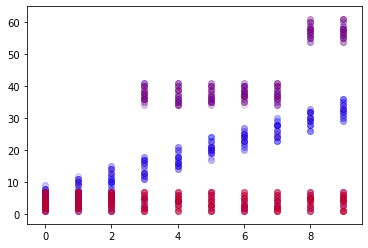

In [112]:
for i in range(10):
    plt.scatter(int_array, M_input[i,:], color = [i/10,0,1-i/10],alpha = np.random.random()/5)

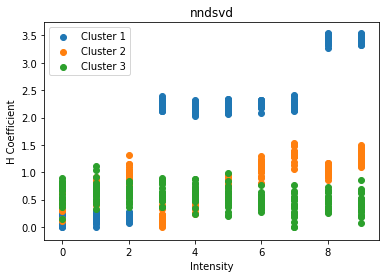

In [114]:

init = 'nndsvd'
# Nonnegative Double Singular Value Decomposition (NNDSVD) 
# initialization (better for sparseness)

rk = 3
[W, H] = get_nnmf(M_input, rk, init, it=2000)
# Plot H coefficient against intesnity
plt.scatter(int_array, H[0], label='Cluster 1')
plt.scatter(int_array, H[1], label='Cluster 2')
plt.scatter(int_array, H[2], label='Cluster 3')
plt.legend()
plt.xlabel ( 'Intensity')
plt.ylabel('H Coefficient')
plt.title(init)
plt.show()

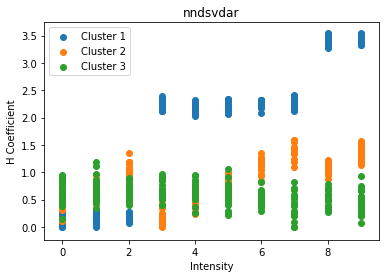

In [115]:
init = 'nndsvdar'

# NNDSVD with zeros filled with small random values 
# (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)

rk = 3
[W, H] = get_nnmf(M_input, rk, init, it=2000)
# Plot H coefficient against intesnity
plt.scatter(int_array, H[0], label='Cluster 1')
plt.scatter(int_array, H[1], label='Cluster 2')
plt.scatter(int_array, H[2], label='Cluster 3')
plt.legend()
plt.xlabel ( 'Intensity')
plt.ylabel('H Coefficient')
plt.title(init)
plt.show()

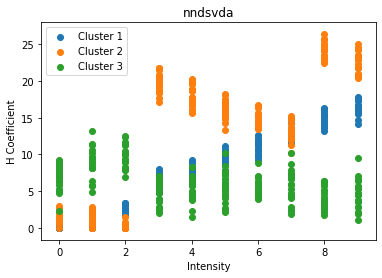

In [116]:
init = 'nndsvda'
rk = 3
[W, H] = get_nnmf(M_input, rk, init, it=2000)
# Plot H coefficient against intesnity
plt.scatter(int_array, H[0], label='Cluster 1')
plt.scatter(int_array, H[1], label='Cluster 2')
plt.scatter(int_array, H[2], label='Cluster 3')
plt.legend()
plt.xlabel ( 'Intensity')
plt.ylabel('H Coefficient')
plt.title(init)
plt.show()

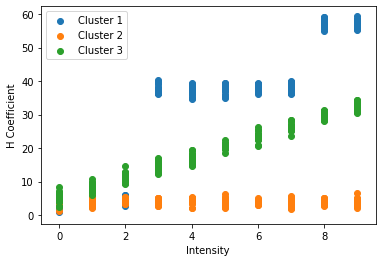

In [118]:
X = M_input
kmeans = KMeans(n_clusters=rk).fit(X)
kmeans.labels_

kmeans.predict(X)

H = kmeans.cluster_centers_
plt.scatter(int_array, H[0], label='Cluster 1')
plt.scatter(int_array, H[1], label='Cluster 2')
plt.scatter(int_array, H[2], label='Cluster 3')
plt.legend()
plt.xlabel('Intensity')
plt.ylabel('H Coefficient')
plt.show()

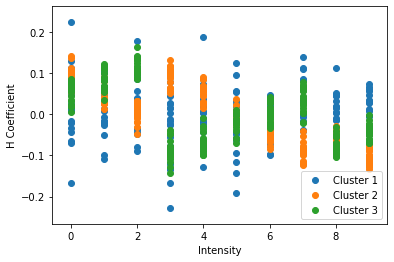

In [119]:
transformer = FastICA(n_components=3,
        random_state=0,
        whiten='unit-variance')
H = transformer.fit_transform(M_input.T)
H = H.T
plt.scatter(int_array, H[0], label='Cluster 1')
plt.scatter(int_array, H[1], label='Cluster 2')
plt.scatter(int_array, H[2], label='Cluster 3')
plt.legend()
plt.xlabel ( 'Intensity')
plt.ylabel('H Coefficient')
plt.show()


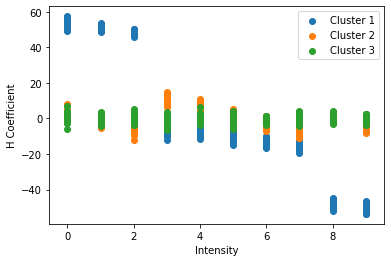

In [120]:
pca = PCA(n_components=3)
H = pca.fit(M_input.T).transform(M_input.T)
H = H.T
rk = 3
plt.scatter(int_array, H[0], label='Cluster 1')
plt.scatter(int_array, H[1], label='Cluster 2')
plt.scatter(int_array, H[2], label='Cluster 3')
plt.legend()
plt.xlabel ( 'Intensity')
plt.ylabel('H Coefficient')
plt.show()


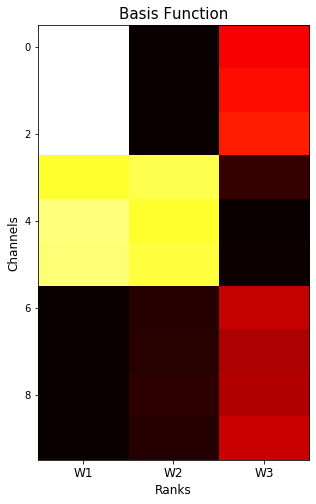

In [121]:
NMFf.plot_W(W,  'Basis Function', file=0)

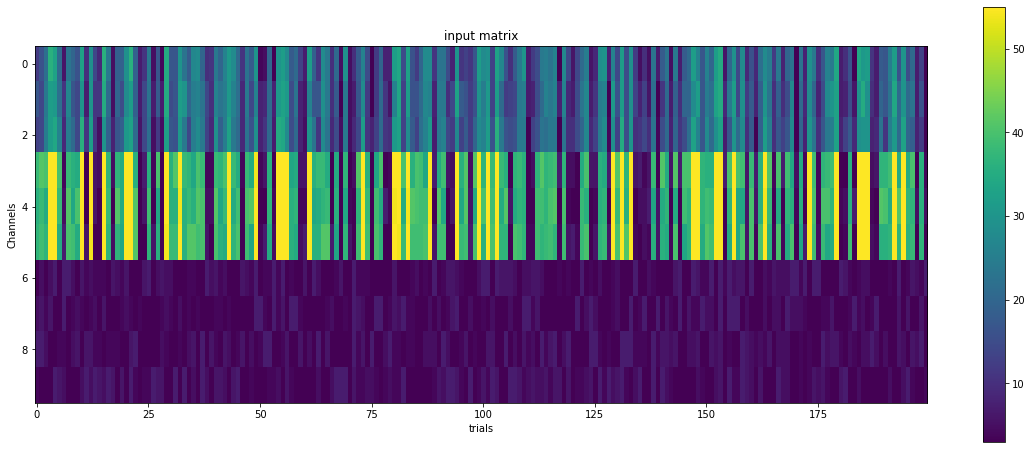

In [122]:
NMFf.plot_V(M_input, 'input matrix' )


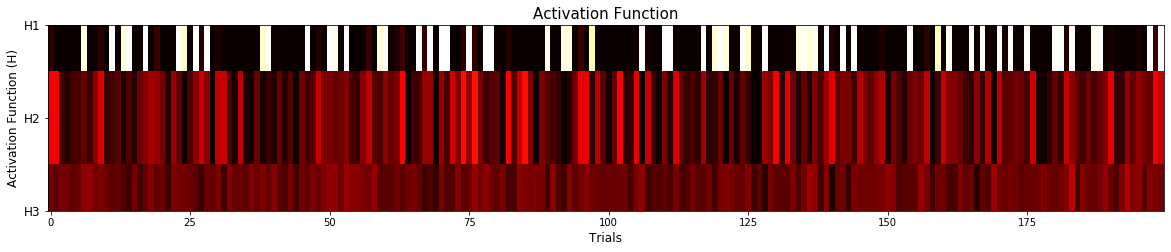

In [123]:
NMFf.plot_H(H,  'Activation Function', file=0)